# Figure 2: Compare across simulations

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import os
import json
import glob
from matplotlib.patches import Patch
import re
import tqdm

In [2]:
base_colors = {"pbfi": "#277da1", "lrp": "#577590", "impacc": "#43aa8b", "split_cloc": "#f9c74f",
    "cloc": "#f8961e", "rampart": "#f94144", "perm": "#e377c2", "cshap": "#780000",}
# dprettier labels
label_map = {"split_cloc": "Split-Cluster LOCO", "cloc": "Cluster LOCOMP", "rampart": "RAMPART \nCluster LOCO",    
    "pbfi": "PBFI", "lrp": "LRP", "impacc": "IMPACC", 'perm':"Permutation", 'cshap':"Fuzzy-KMeans SHAP"}

To reproduce this figure you should run the scripts under `scripts/*`, this will create the `.json` files and experiments.

## Load and parse data

In [3]:
names = ['gaussian_20', 'gaussian_50', 'gaussian_200', 'gaussian_500', 'gaussian_1000',
        'moons_20', 'moons_50', 'moons_200', 'moons_500', 'moons_1000',
        'gamma_20', 'gamma_50', 'gamma_200', 'gamma_500', 'gamma_1000']

In [4]:
def build_avg_df(results): # for results under ./scripts/results 
    if isinstance(results, dict):
        results = [results]

    def scalar(x):
        x = np.asarray(x)
        return x.item() if x.size == 1 else x

    rows = []
    for r in results:
        # Metadata saved directly in each .npz result file
        task_id = scalar(r["task_id"])
        informative_d = scalar(r["informative_d"])
        noise_d = scalar(r["noise_d"])

        experiment = scalar(r["experiment"])
        difficulty = scalar(r["difficulty"])
        sim_method = scalar(r["sim_method"])
        alpha = scalar(r["alpha"])

        methods = [key.replace("topk_hits_", "") for key in r if key.startswith("topk_hits_")]

        for method in methods:
            topk_vals = np.asarray(r[f"topk_hits_{method}"], dtype=float)
            time_vals = np.asarray(r[f"time_{method}"], dtype=float)
            ari_key = f"ari_{method}"
            ari_vals = np.asarray(r[ari_key], dtype=float) if ari_key in r else np.array([np.nan])
            
            rows.append({
                    "task_id": task_id,
                    "experiment": experiment,
                    "source": sim_method,
                    "difficulty": difficulty,
                    "alpha": alpha,
                    "informative_d": informative_d,
                    "noise_d": noise_d,
                    "p": informative_d + noise_d,
                    "method": method,

                    "ari_mean": np.nanmean(ari_vals),
                    "ari_se": np.nanstd(ari_vals, ddof=1) / np.sqrt(len(ari_vals)) if len(ari_vals) > 1 else 0.0,

                    "topk_hits_mean": np.mean(topk_vals),
                    "topk_hits_se": np.std(topk_vals, ddof=1) / np.sqrt(len(topk_vals)) if len(topk_vals) > 1 else 0.0,

                    "time_mean": np.mean(time_vals),
                    "time_se": np.std(time_vals, ddof=1) / np.sqrt(len(time_vals)) if len(time_vals) > 1 else 0.0,
                })
    return pd.DataFrame(rows)

In [5]:
def build_avg_df(results): # for results under ./scripts/results_new/
    if isinstance(results, dict):
        results = [results]

    def scalar(x):
        x = np.asarray(x)
        return x.item() if x.size == 1 else x

    rows = []

    for r in results:
        # Direct metadata
        task_id = scalar(r["task_id"])
        informative_d = scalar(r["informative_d"])
        noise_d = scalar(r["noise_d"])
        # Recover merged experiment configuration
        runtime_config = scalar(r["runtime_config"])
        if isinstance(runtime_config, bytes):
            runtime_config = runtime_config.decode("utf-8")

        cfg = json.loads(runtime_config)

        experiment = cfg.get("setting_name")
        difficulty = cfg.get("difficulty")
        sim_method = cfg.get("sim_method")
        alpha = cfg.get("alpha")
        # Methods stored in NPZ
        methods = [key.replace("topk_hits_", "") for key in r if key.startswith("topk_hits_")]

        for method in methods:
            topk_vals = np.asarray(r[f"topk_hits_{method}"], dtype=float)
            time_vals = np.asarray(r[f"time_{method}"], dtype=float)
            ari_key = f"ari_{method}"
            ari_vals = (np.asarray(r[ari_key], dtype=float) if ari_key in r else np.array([np.nan]))

            rows.append({
                "task_id": task_id,
                # experiment metadata
                "experiment": experiment,
                "source": sim_method,
                "difficulty": difficulty,
                "alpha": alpha,
                # dimensionality metadata
                "informative_d": informative_d,
                "noise_d": noise_d,
                "p": informative_d + noise_d,
                # method
                "method": method,
                # clustering difficulty
                "ari_mean": np.nanmean(ari_vals),
                "ari_se": (np.nanstd(ari_vals, ddof=1) / np.sqrt(len(ari_vals)) if len(ari_vals) > 1 else 0.0),
                # feature recovery
                "topk_hits_mean": np.nanmean(topk_vals),
                "topk_hits_se": (np.nanstd(topk_vals, ddof=1) / np.sqrt(len(topk_vals)) if len(topk_vals) > 1 else 0.0),
                # runtime
                "time_mean": np.nanmean(time_vals),
                "time_se": (np.nanstd(time_vals, ddof=1) / np.sqrt(len(time_vals)) if len(time_vals) > 1 else 0.0),
            })
    return pd.DataFrame(rows)

In [6]:
folder = '../scripts/results_2000/' 

In [7]:
files = sorted(glob.glob(os.path.join(folder,"**","results_task*.npz"),recursive=True))

print(f"Found {len(files)} result files.")

all_results = []

for f in tqdm.tqdm(files, desc="Loading result files"):
    with np.load(f, allow_pickle=False) as data:
        result_dict = {key: data[key] for key in data.files}
    all_results.append(result_dict)

df_avg = build_avg_df(all_results)

Found 19 result files.


Loading result files: 100%|█████████████████████| 19/19 [00:00<00:00, 19.34it/s]


## Run time comparison

In [8]:
df_avg.head()

,task_id,experiment,source,difficulty,alpha,informative_d,noise_d,p,method,ari_mean,ari_se,topk_hits_mean,topk_hits_se,time_mean,time_se
0,0,gaussian_1000,gaussian,easy,2.2,10,990,1000,pbfi,0.966510,0.022403,1.00,0.000000,0.093705,0.001609
1,0,gaussian_1000,gaussian,easy,2.2,10,990,1000,lrp,0.966510,0.022403,1.00,0.000000,0.755786,0.178473
2,0,gaussian_1000,gaussian,easy,2.2,10,990,1000,impacc,0.773814,0.072463,0.97,0.015275,9.378096,0.196588
3,0,gaussian_1000,gaussian,easy,2.2,10,990,1000,split_cloc,0.966510,0.022403,0.00,0.000000,72.679263,0.989109
4,0,gaussian_1000,gaussian,easy,2.2,10,990,1000,cloc,0.888490,0.030396,0.99,0.010000,43.208122,0.250248


In [9]:
df_grouped = df_avg[['method','noise_d', 'source','difficulty','time_mean', 'time_se', 'topk_hits_mean','ari_mean']]
df_grouped.head()

,method,noise_d,source,difficulty,time_mean,time_se,topk_hits_mean,ari_mean
0,pbfi,990,gaussian,easy,0.093705,0.001609,1.00,0.966510
1,lrp,990,gaussian,easy,0.755786,0.178473,1.00,0.966510
2,impacc,990,gaussian,easy,9.378096,0.196588,0.97,0.773814
3,split_cloc,990,gaussian,easy,72.679263,0.989109,0.00,0.966510
4,cloc,990,gaussian,easy,43.208122,0.250248,0.99,0.888490


In [10]:
method_ag = ['split_cloc', 'cloc', 'rampart', 'perm','impacc']
method_km = ['pbfi', 'cshap','lrp'] 

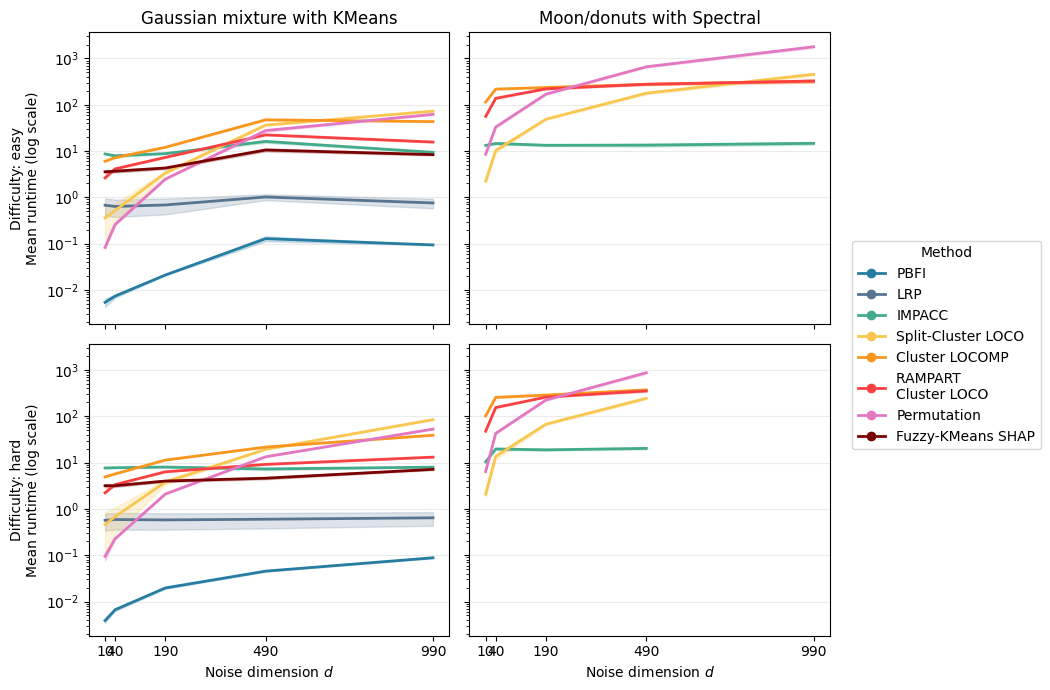

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

method_order = list(base_colors.keys())
noise_order = sorted(df_grouped["noise_d"].unique())
difficulty_order = sorted(df_grouped["difficulty"].unique())
source_order = list(df_grouped["source"].unique())
title = {'gamma': "Gamma mixture with EM", 'gaussian': 'Gaussian mixture with KMeans', 'moon-donut':'Moon/donuts with Spectral'}
fig, ax = plt.subplots(len(difficulty_order), len(source_order), figsize=(5 * len(source_order), 3.5 * len(difficulty_order)),
    sharex=True, sharey=True, squeeze=False)

for i, difficulty in enumerate(difficulty_order):
    for j, source in enumerate(source_order):
        if source == 'gaussian': 
            plot_df = (df_grouped.loc[(df_grouped["source"] == source) 
                & (df_grouped["difficulty"] == difficulty)] 
                .sort_values("noise_d"))
        else:
            plot_df = (df_grouped.loc[(df_grouped["source"] == source) 
                & (df_grouped["difficulty"] == difficulty)
                & (df_grouped["method"].isin(method_ag))] # only agnostic methods
                .sort_values("noise_d"))
            
        sns.lineplot(data=plot_df, x="noise_d", y="time_mean", hue="method",
            hue_order=method_order, palette=base_colors, # marker="o",
            linewidth=2, markersize=5, errorbar='se', legend=False, ax=ax[i, j])
    
        for method in method_order:
            method_df = plot_df.loc[plot_df["method"] == method]
            if method_df.empty:
                continue

            ax[i, j].fill_between(method_df["noise_d"], method_df["time_mean"]-method_df["time_se"], method_df["time_mean"]+method_df["time_se"],
                alpha=0.2, color=base_colors[method])
        ax[i, j].set_yscale("log")
        ax[i, j].grid(axis="y", alpha=0.25)
        if i == 0:
            ax[i, j].set_title(title[source])
        if j == 0:
            ax[i, j].set_ylabel(f"Difficulty: {difficulty}\nMean runtime (log scale)")
        else:
            ax[i, j].set_ylabel("")
        if i == len(difficulty_order) - 1:
            ax[i, j].set_xlabel(r"Noise dimension $d$")
        else:
            ax[i, j].set_xlabel("")
        ax[i, j].set_xticks(noise_order)
legend_handles = [Line2D([0], [0], color=base_colors[method], marker="o", linewidth=2, label=label_map[method])
                  for method in method_order]
fig.legend(handles=legend_handles, title="Method", loc="center left", bbox_to_anchor=(0.85, 0.5))
fig.tight_layout(rect=[0, 0, 0.85, 1])
#fig.savefig('./figures/runtime_simulations.pdf')

In [26]:
df_grouped.head()

,method,noise_d,source,difficulty,time_mean,time_se,topk_hits_mean,ari_mean
0,pbfi,990,gaussian,easy,0.093705,0.001609,1.00,0.966510
1,lrp,990,gaussian,easy,0.755786,0.178473,1.00,0.966510
2,impacc,990,gaussian,easy,9.378096,0.196588,0.97,0.773814
3,split_cloc,990,gaussian,easy,72.679263,0.989109,0.00,0.966510
4,cloc,990,gaussian,easy,43.208122,0.250248,0.99,0.888490


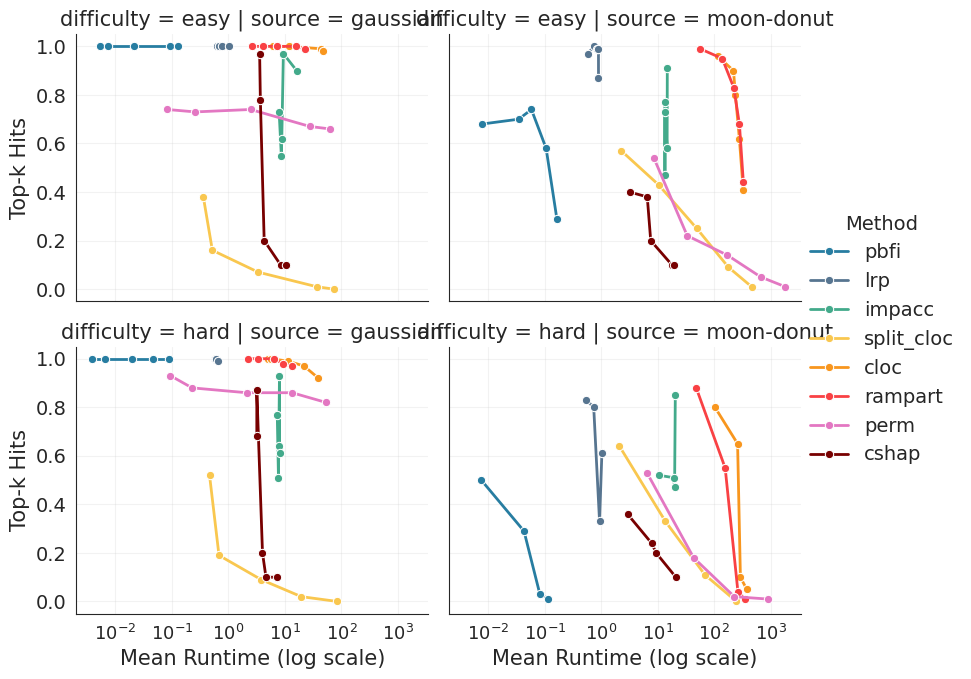

In [33]:
# Facet by source and difficulty, plotting quality directly against runtime
g = sns.FacetGrid(df_grouped, col="source", row="difficulty", height=3.5, aspect=1.2)

g.map_dataframe(
    sns.lineplot,
    x="time_mean",
    y="topk_hits_mean",
    hue="method",
    palette=base_colors,
    marker="o",
    linewidth=2
)
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.grid(True, alpha=0.25)

g.set_axis_labels("Mean Runtime (log scale)", "Top-k Hits")
g.add_legend(title="Method")

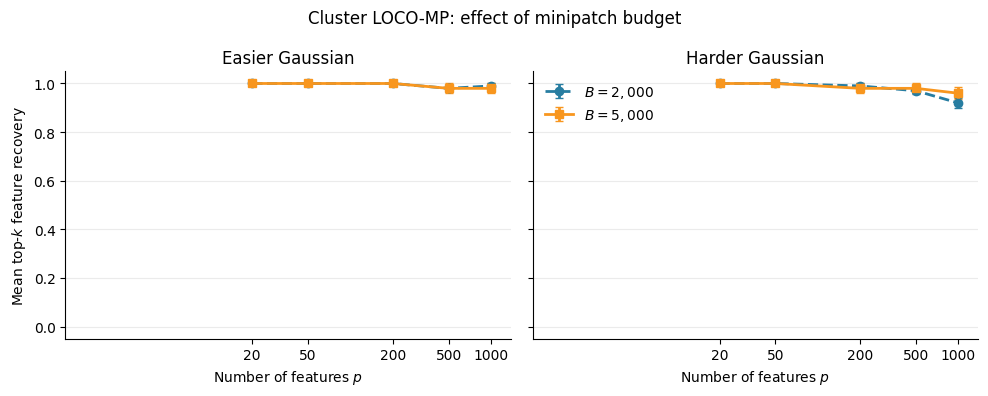

In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths relative to the notebook directory
folders = {
    2000: Path("../scripts/results_2000"),
    5000: Path("../scripts/results"),
}

# Collect individual simulation repetitions
rows = []
for budget, folder in folders.items():
    for path in sorted(folder.rglob("results_task*.npz")):
        with np.load(path, allow_pickle=False) as data:
            def scalar(key):
                return np.asarray(data[key]).item()

            # The two folders use different metadata formats
            if "runtime_config" in data:
                cfg = json.loads(scalar("runtime_config"))
                source = cfg["sim_method"]
                difficulty = cfg["difficulty"]
            else:
                source = scalar("sim_method")
                difficulty = scalar("difficulty")

            if source != "gaussian":
                continue

            p = int(scalar("informative_d") + scalar("noise_d"))
            values = np.asarray(
                data["topk_hits_cloc"], dtype=float
            ).ravel()

            for value in values:
                if np.isfinite(value):
                    rows.append({
                        "B": budget,
                        "difficulty": difficulty,
                        "p": p,
                        "recovery": value,
                    })

df_budget = pd.DataFrame(rows)
if df_budget.empty:
    raise ValueError("No Gaussian results found. Check the folder paths.")

summary = (
    df_budget.groupby(["B", "difficulty", "p"])["recovery"]
    .agg(mean="mean", se="sem", n="count")
    .reset_index()
)

styles = {
    2000: dict(color="#277da1", marker="o", linestyle="--"),
    5000: dict(color="#f8961e", marker="s", linestyle="-"),
}

fig, axes = plt.subplots(
    1, 2, figsize=(10, 4), sharex=True, sharey=True
)
p_values = sorted(summary["p"].unique())

for ax, difficulty, title in zip(
    axes, ["easy", "hard"], ["Easier Gaussian", "Harder Gaussian"]
):
    for budget, style in styles.items():
        subset = summary[
            (summary["difficulty"] == difficulty)
            & (summary["B"] == budget)
        ].sort_values("p")

        ax.errorbar(
            subset["p"],
            subset["mean"],
            yerr=subset["se"],
            label=rf"$B={budget:,}$",
            linewidth=2,
            markersize=6,
            capsize=3,
            **style,
        )

    ax.set_xscale("log")
    ax.set_xticks(p_values)
    ax.set_xticklabels([str(p) for p in p_values])
    ax.minorticks_off()
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(r"Number of features $p$")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel(r"Mean top-$k$ feature recovery")
axes[1].legend(frameon=False)
fig.suptitle("Cluster LOCO-MP: effect of minipatch budget")
fig.tight_layout()

# Optional:
# fig.savefig("figures/gaussian_budget_comparison.pdf",
#             bbox_inches="tight")

plt.show()

## Plot experiments' results

In [13]:
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
})

# -----------------------------
# Configuration
# -----------------------------
order = [
    "RAMPART \nCluster LOCO",
    "Cluster LOCOMP",
    "Split-Cluster LOCO",
    "PBFI",
    "Fuzzy-KMeans SHAP",
    "LRP",
    "IMPACC",
    "Permutation",
]

# -----------------------------
# Helpers
# -----------------------------
def build_y_positions(method_order, p_values, gap=1.4):
    y_positions = {}
    group_centers = {}
    current_y = 0
    n_methods = len(method_order)

    for p in p_values:
        start_y = current_y
        for m in method_order:
            y_positions[(p, m)] = current_y
            current_y += 1
        end_y = current_y - 1
        group_centers[p] = (start_y + end_y) / 2
        current_y += gap

    return y_positions, group_centers, n_methods


def draw_group_separators(ax, p_values, n_methods, gap):
    for k in range(len(p_values) - 1):
        sep_y = (k + 1) * n_methods + k * gap + gap / 2 - 0.5
        ax.axhline(sep_y, color="0.82", lw=1.2, zorder=0)


def style_axis(ax, title, group_centers, p_values):
    ax.set_title(title, pad=12, weight="semibold")
    ax.set_yticks([group_centers[p] for p in p_values])
    ax.set_yticklabels([rf"$p={p}$" for p in p_values], fontweight="bold")
    ax.set_ylabel("")
    ax.set_xlabel("Top-k hits", labelpad=8)

    ax.grid(axis="x", color="0.88", linewidth=1)
    ax.set_axisbelow(True)

    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)
    ax.invert_yaxis()


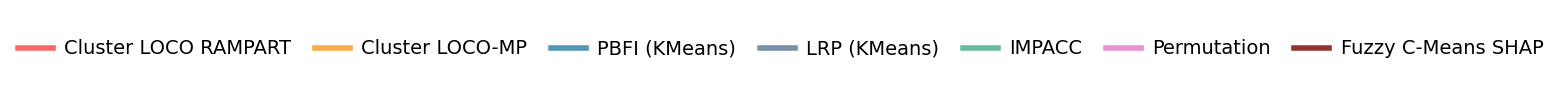

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
base_colors = {
    "rampart": "#f94144",
    "cloc": "#f8961e",
    "pbfi": "#277da1",
    "lrp": "#577590",
    "impacc": "#43aa8b",
    "perm": "#e377c2",
    "cshap": "#780000",
}
label_map = {
    "rampart": "Cluster LOCO RAMPART",
    "cloc": "Cluster LOCO-MP",
    "pbfi": "PBFI (KMeans)",
    "lrp": "LRP (KMeans)",
    "impacc": "IMPACC",
    "perm": "Permutation",
    "cshap": "Fuzzy C-Means SHAP",
}
order = ["rampart", "cloc", "pbfi", "lrp", "impacc", "perm", "cshap"]
handles = [Line2D([0], [0], color=base_colors[m], lw=4, marker="o", markersize=0, label=label_map[m], alpha=0.8)
    for m in order]

fig, ax = plt.subplots(figsize=(10, 1.2))
ax.axis("off")
legend = ax.legend(handles=handles, loc="center", ncol=len(order), frameon=False,
    handlelength=1.8, handletextpad=0.6, columnspacing=1.2, fontsize=14)
fig.tight_layout()
# optional
fig.savefig("./figures/fig2_legend.pdf", bbox_inches="tight", dpi=300)
# fig.savefig("legend_only.png", bbox_inches="tight", dpi=300)
plt.show()

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re

def get_lineplot_parentheses_labels(df_avg, source, difficulty, p_order=[20, 50, 200, 500, 1000], title='', figsize=(10, 6), save=False, save_file=None, base_clusterer='Spectral', **kwargs):
    # 1. Data Filtering
    df = df_avg[(df_avg.source == source) & 
        (df_avg.difficulty == difficulty) & 
        (df_avg["p"].isin(p_order))
    ].copy()

    base_colors = {"pbfi": "#277da1", "lrp": "#577590", "impacc": "#43aa8b",
        "perm": "#e377c2", "cshap": "#780000", "cloc": "#f8961e", "rampart": "#f94144"}
    
    # Mapping for Internal Logic
    label_map = {"rampart": f"RAMPART ({base_clusterer})",   
        "cloc": f"Cluster LOCOMP ({base_clusterer})",
        "pbfi": "PBFI (KMeans)",
        "lrp": "LRP (KMeans)",
        "impacc": f"IMPACC ({base_clusterer})",
        "perm": f"Permutation ({base_clusterer})",
        "cshap": "Fuzzy C-Means (FCM)"}

    # Ensure RAMPART plots on top
    plot_order = ["pbfi", "lrp", "impacc", "perm", "cshap", "cloc", "rampart"]
    plot_order_pretty = [label_map[m] for m in plot_order]
    
    df['method_pretty'] = df['method'].map(label_map)
    df['method_pretty'] = pd.Categorical(df['method_pretty'], categories=plot_order_pretty, ordered=True)
    
    pretty_palette = {label_map.get(k, k): v for k, v in base_colors.items()}
    # print(df.head())
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_style("white")
        # Plot without legend
    # Make sure the SE column exists for test runs / one-replicate groups
    if "topk_hits_se" not in df.columns:
        df["topk_hits_se"] = 0.0
    df["topk_hits_se"] = df["topk_hits_se"].fillna(0.0)
    sns.lineplot(data=df, x="p", y="topk_hits_mean", hue="method_pretty",
        hue_order=plot_order_pretty, palette=pretty_palette, # marker="o",
        dashes=False, linewidth=4, alpha=0.8, errorbar=None, legend=False, ax=ax)
    
    for method in plot_order_pretty:
        method_df = df.loc[df["method_pretty"] == method].sort_values("p")
        if method_df.empty:
            continue
    
        ax.fill_between(method_df["p"].to_numpy(dtype=float),
            (method_df["topk_hits_mean"] - method_df["topk_hits_se"]).to_numpy(dtype=float),
            (method_df["topk_hits_mean"] + method_df["topk_hits_se"]).to_numpy(dtype=float),
            alpha=0.2, color=pretty_palette[method])
    ax.set_xscale('log')
    ax.set_xticks(p_order)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

    # 2. EXTRACT PARENTHESES AND LABEL
    last_p = max(p_order)
    
    for method_full_name in plot_order_pretty:
        method_data = df[df['method_pretty'] == method_full_name]
        if not method_data.empty:
            y_val = method_data[method_data['p'] == last_p]['topk_hits_mean'].mean()
            color = pretty_palette[method_full_name]

    # Styling
    ax.set_xlim(min(p_order), last_p) # Adjusted for shorter labels
    ax.set_ylabel(r"Top-$k$ Hits", fontsize=12)
    ax.set_xlabel(r"Number of Features $p$", fontsize=12)
    ax.set_title(title, pad=15)
    sns.despine()

    if save:
        fig.savefig(save_file, dpi=300, bbox_inches='tight')
    
    return fig, ax

In [16]:
df = df_avg[df_avg.method != 'split_cloc'].copy()

In [17]:
df.head(2)

,task_id,experiment,source,difficulty,alpha,informative_d,noise_d,p,method,ari_mean,ari_se,topk_hits_mean,topk_hits_se,time_mean,time_se
0,0,gaussian_1000,gaussian,easy,2.2,10,990,1000,pbfi,0.96651,0.022403,1.0,0.0,0.093705,0.001609
1,0,gaussian_1000,gaussian,easy,2.2,10,990,1000,lrp,0.96651,0.022403,1.0,0.0,0.755786,0.178473


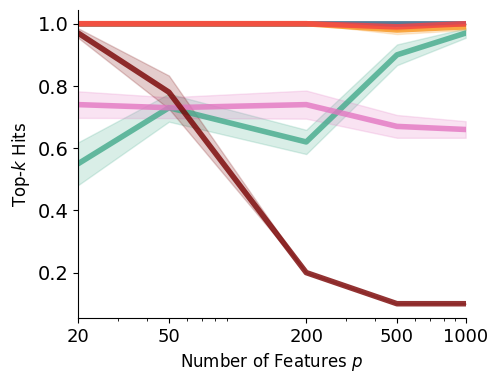

In [18]:
fig, ax = get_lineplot_parentheses_labels(df, 'gaussian', 'easy', title='', figsize=(5, 4), base_clusterer ='KMeans', save=True, save_file='./figures/fig2_GMM_easier.pdf')

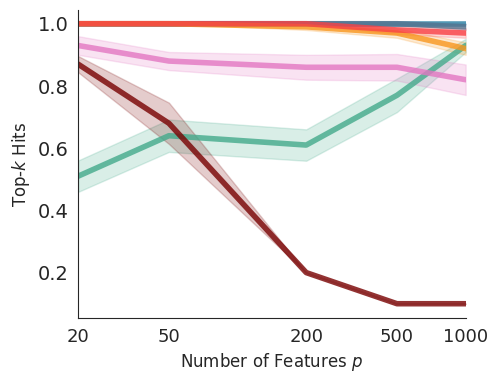

In [19]:
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gaussian', 'hard', title='', figsize=(5, 4),base_clusterer ='KMeans', save=True,  save_file='./figures/fig2_GMM_harder.pdf')

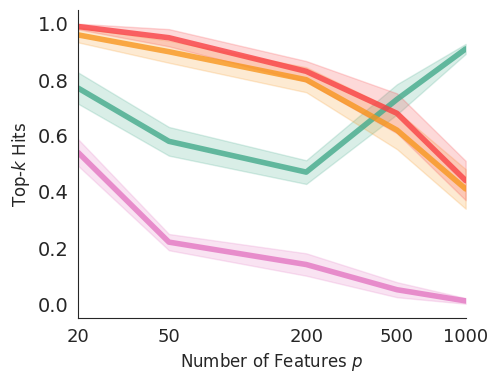

In [20]:
fig, ax = get_lineplot_parentheses_labels(df_avg[df_avg.method.isin(method_ag)], 'moon-donut', 'easy', figsize=(5, 4), base_clusterer ='Spectral', save=True, save_file='./figures/fig2_MC_easier.pdf') # title='Moons and Circles (easier)')

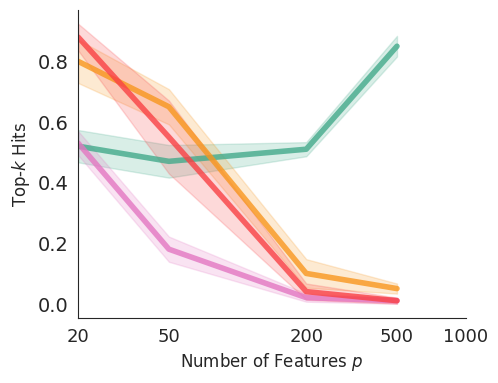

In [21]:
fig, ax = get_lineplot_parentheses_labels(df_avg[df_avg.method.isin(method_ag)], 'moon-donut', 'hard',  figsize=(5, 4),base_clusterer ='Spectral', save=True, save_file='./figures/fig2_MC_harder.pdf')#  title='Moons and Circles (harder)',

/burg/morphogenomics-lab/users/grp_tmpdir/ipykernel_1929980/3068902121.py:41: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df, x="p", y="topk_hits_mean", hue="method_pretty",


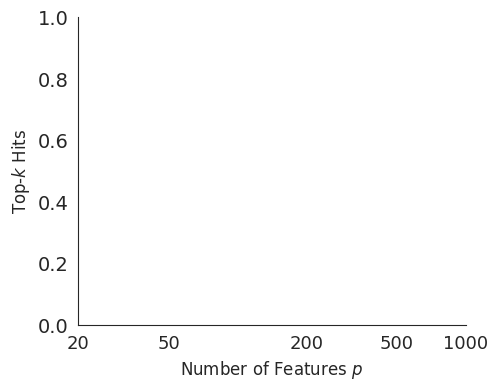

In [22]:
fig, ax = get_lineplot_parentheses_labels(df_avg[df_avg.method.isin(method_ag)], 'gamma', 'easy', figsize=(5, 4),base_clusterer ='Gamma Mixture',  save=True, save_file='./figures/fig2_GammaMM_easier.pdf') #  title='Gamma mixture (easier)',

/burg/morphogenomics-lab/users/grp_tmpdir/ipykernel_1929980/3068902121.py:41: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df, x="p", y="topk_hits_mean", hue="method_pretty",


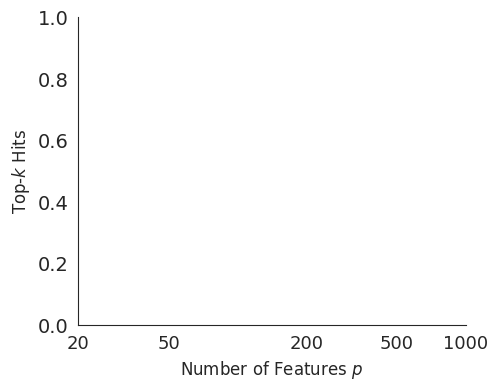

In [23]:
fig, ax = get_lineplot_parentheses_labels(df_avg[df_avg.method.isin(method_ag)], 'gamma', 'hard', base_clusterer ='Gamma Mixture', figsize=(5, 4), save=True, save_file='./figures/fig2_GammaMM_harder.pdf') #  title='Gamma mixture (harder)', save_file='../figures/fig2_GammaMM_harder.pdf')

## Data in PC-space

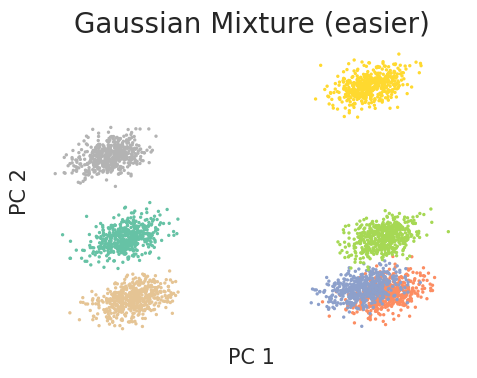

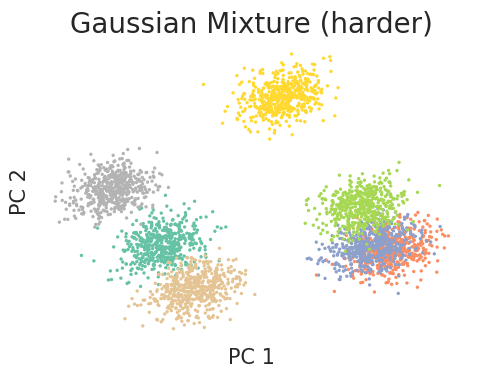

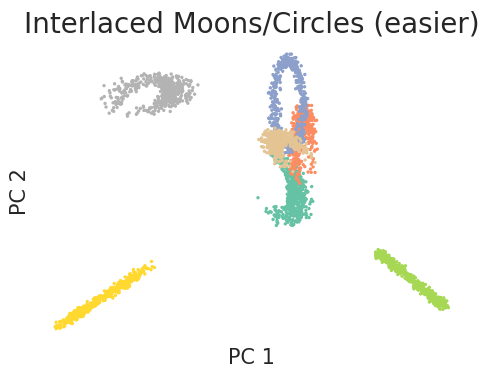

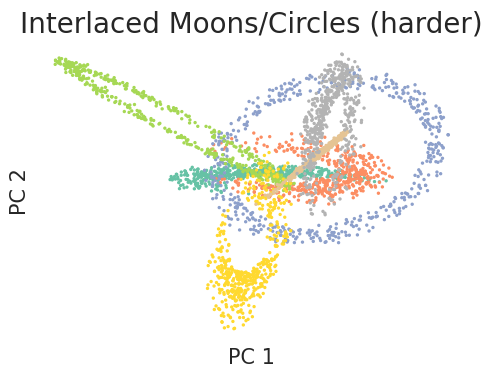

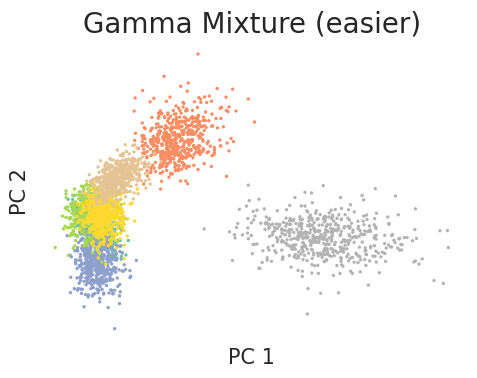

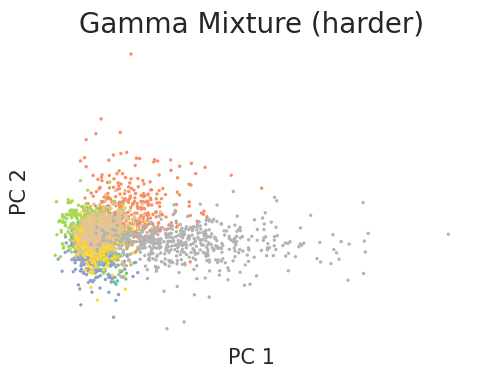

In [45]:
import sys
sys.path.append("../")

from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from clim.simulations.simulators import *


def get_noise_d(exp):
    """
    Total number of noise dimensions from experiment config.

    Supports either:
      exp["noise_plan"] = [{"type": "...", "d": ...}, ...]
    or:
      exp["noise_d"]
    """
    if "noise_plan" in exp and exp["noise_plan"] is not None:
        return int(sum(int(block.get("d", 0)) for block in exp["noise_plan"]))

    if "noise_d" in exp:
        return int(exp["noise_d"])

    return 0


def config_to_generator_kwargs(cfg):
    """
    Convert a JSON config dictionary into arguments expected by
    generate_dataset_for_one_run().

    Expected flexible structure:

    cfg = {
        "experiment": {
            "sim_method": "...",
            "sim_seed": 0,
            "embed_seed": 0,
            "K": 3,
            "n_per_cluster": 100,
            "alpha": 1.0,
            "d0": 2,
            "gaps": ...,
            "shape_probs": ...,
            "oversample": 1.0,
            "informative_d": 10,
            "noise_plan": [...]
        }
    }

    Also supports some alternate key names.
    """
    exp = cfg.get("experiment", cfg)

    sim_method = (
        exp.get("sim_method")
        or exp.get("method")
        or exp.get("simulation")
        or exp.get("simulator")
    )

    if sim_method is None:
        raise KeyError(
            "Could not find simulation method. Expected one of "
            "'sim_method', 'method', 'simulation', or 'simulator'."
        )

    K = int(exp.get("K", exp.get("n_clusters", 3)))
    n_per_cluster = int(
        exp.get(
            "n_per_cluster",
            exp.get("n_samples_per_cluster", exp.get("cluster_size", 100)),
        )
    )

    d0 = int(exp.get("d0", exp.get("d_0", exp.get("signal_base_d", 2))))
    informative_d = int(exp.get("informative_d", exp.get("d_s", d0)))

    noise_plan = exp.get("noise_plan", None)

    if noise_plan is None:
        noise_d = int(exp.get("noise_d", exp.get("d_n", 0)))
        noise_type = exp.get("noise_type", "gaussian")
        noise_plan = []
        if noise_d > 0:
            noise_plan.append({"type": noise_type, "d": noise_d})

    return {
        "sim_method": sim_method,
        "sim_seed": int(exp.get("sim_seed", exp.get("random_state", exp.get("seed", 0)))),
        "embed_seed": int(exp.get("embed_seed", exp.get("projection_seed", exp.get("seed", 0)))),
        "K": K,
        "n_per_cluster": n_per_cluster,
        "alpha": float(exp.get("alpha", 1.0)),
        "d0": d0,
        "gaps": exp.get("gaps", None),
        "shape_probs": exp.get("shape_probs", None),
        "oversample": float(exp.get("oversample", 1.0)),
        "informative_d": informative_d,
        "noise_plan": noise_plan,
    }


def extract_panel_keys(cfg):
    """
    Extract display keys from config.

    Returns
    -------
    sim_method : str
    p_regime : str
    """
    exp = cfg.get("experiment", cfg)

    sim_method = (
        exp.get("sim_method")
        or exp.get("method")
        or exp.get("simulation")
        or exp.get("simulator")
        or "unknown"
    )

    p_regime = (
        exp.get("p_regime")
        or exp.get("regime")
        or exp.get("difficulty")
        or exp.get("setting")
        or "unknown"
    )

    return sim_method, p_regime

def plot_pca_clusters_on_ax(ax, X_aug, y, title=None):
    X = StandardScaler().fit_transform(X_aug)
    X_pca = PCA(n_components=2).fit_transform(X)

    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        s=2,
        c=y,
        cmap="Set2"
    )

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    if title is not None:
        ax.set_title(title, fontsize=20)



def generate_dataset_for_one_run(
    *,
    sim_method: str,
    sim_seed: int,
    embed_seed: int,
    K: int,
    n_per_cluster: int,
    alpha: float,
    d0: int,
    gaps,
    shape_probs,
    oversample: float,
    informative_d: int,
    noise_plan: list,
):
    """
    Generate one simulated high-dimensional clustering dataset.

    noise_plan examples:
        [
            {"type": "gaussian", "d": 10},
            {"type": "student-t", "d": 10, "df": 10},
            {"type": "triangular", "d": 10, "low": -1, "high": 1},
            {"type": "laplace", "d": 10, "scale": 1.0},
            {"type": "permuted", "d": 10},
            {"type": "uniform", "d": 10},
        ]
    """
    # Optional: generate covariances if your simulator uses this elsewhere.
    # Kept from your original code, but not passed to BaseSimulator here.
    _ = [
        GenerateCovariances(
            dim=d0,
            covMethod="onion",
            eta=1 / (k + 1),
        ).covGen()[0]
        for k in range(K)
    ]

    sim = BaseSimulator(
        K=K,
        n_samples_per_cluster=n_per_cluster,
        alpha=alpha,
        d_0=d0,
        method=sim_method,
        gaps=gaps,
        shape_probs=shape_probs,
        oversample=oversample,
        random_state=sim_seed,
    )

    X, y = sim.generate_data()

    # Project signal to informative dimensions using embed_seed.
    rng_saved = sim.rng
    sim.rng = np.random.default_rng(embed_seed)

    if informative_d - d0 > 0:
        sim.project_higher_dim(
            embed_dim=informative_d - d0,
            method="orthogonal",
            gamma=1,
            degree=5,
            label_aware=True,
        )

    sim.rng = rng_saved

    # Use a local RNG for reproducible custom noise operations.
    noise_rng = np.random.default_rng(embed_seed + 10_000)

    for block in noise_plan:
        nt = block["type"]
        d = int(block["d"])
        kw = {k: v for k, v in block.items() if k not in ("type", "d")}

        if d <= 0:
            continue

        if nt == "permuted":
            random_features = noise_rng.choice(
                np.arange(sim.X.shape[1]),
                size=d,
                replace=True,
            )
            X_noise = np.array(
                [permute_feature(sim.X, rd_feat) for rd_feat in random_features]
            ).T
            sim.X = np.concatenate([sim.X, X_noise], axis=1)

        elif nt == "uniform":
            sim.add_noise(
                noise_d=d,
                noise_type=nt,
                low=np.min(sim.X),
                high=np.max(sim.X),
            )

        else:
            sim.add_noise(noise_d=d, noise_type=nt, **kw)

    X_aug = sim.X

    # For manifold simulations, preserve original low-dimensional manifold coordinates.
    if sim_method in {"moon-donut", "swiss-roll"}:
        X_aug = np.concatenate([X, X_aug], axis=1)

    return X_aug, y


def plot_config_file_pca(config_path, save_path=None, title=None, palette='tab10'):
    config_path = Path(config_path)

    with open(config_path, "r") as f:
        cfg = json.load(f)

    kwargs = config_to_generator_kwargs(cfg)
    X_aug, y = generate_dataset_for_one_run(**kwargs)

    sim_method, p_regime = extract_panel_keys(cfg)
    exp = cfg.get("experiment", cfg)

    informative_d = int(exp.get("informative_d", exp.get("d_s", kwargs["informative_d"])))
    noise_d = get_noise_d(exp)

    if title is None:
        title = (
            f"{config_path.name}\n"
            rf"{sim_method}, $p={p_regime}$ "
            rf"($d_s={informative_d}, d_n={noise_d}$)"
        )

    fig, ax = plt.subplots(figsize=(5, 4))

    plot_pca_clusters_on_ax(
        ax=ax,
        X_aug=X_aug,
        y=y,
        title=title,
    )

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=250, bbox_inches="tight")

    plt.show()

    return fig, ax, X_aug, y


names = [
    "../scripts/hde/hde1_gaussian.json",
    "../scripts/hde/hde1_gaussian_medium.json",
    "../scripts/hde/hde0_moon_easy.json",
    "../scripts/hde/hde0_moon.json",
    "../scripts/hde/hde2_gamma.json",
    "../scripts/hde/hde2_gamma_alpha1.json",
]

difficulty = np.tile(["easier", "harder"], 3)
simu = np.repeat(
    ["Gaussian Mixture", "Interlaced Moons/Circles", "Gamma Mixture"],
    2,
)
path_sim = np.repeat(["gaussian", "moons", "gamma"], 2)

for i, config_name in enumerate(names):
    plot_config_file_pca(
        config_name,
        save_path=f"../figures/{path_sim[i]}_{difficulty[i]}.pdf",
        title=f"{simu[i]} ({difficulty[i]})",
    )

In [36]:
def plot_config_file_pca(config_path, save_path=None, title=None):
    config_path = Path(config_path)

    with open(config_path, "r") as f:
        cfg = json.load(f)

    kwargs = config_to_generator_kwargs(cfg)
    X_aug, y = generate_dataset_for_one_run(**kwargs)

    sim_method, p_regime = extract_panel_keys(cfg)
    exp = cfg["experiment"]
    informative_d = int(exp["informative_d"])
    noise_d = get_noise_d(exp)

    if title is None:
        title = (
            f"{config_path.name}\n"
            rf"{sim_method}, $p={p_regime}$ "
            rf"($d_s={informative_d}, d_n={noise_d}$)"
        )

    fig, ax = plt.subplots(figsize=(5, 4.5))

    plot_pca_clusters_on_ax(
        ax=ax,
        X_aug=X_aug,
        y=y,
        title=title
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=250, bbox_inches="tight")

    plt.show()

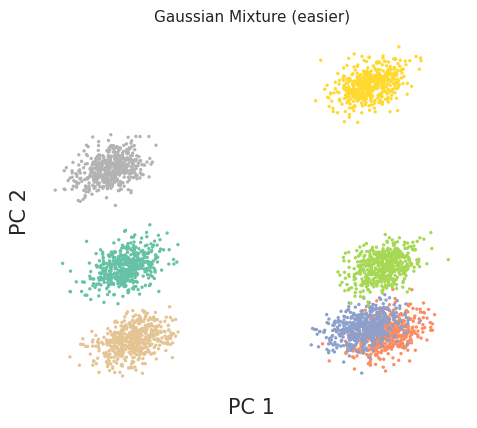

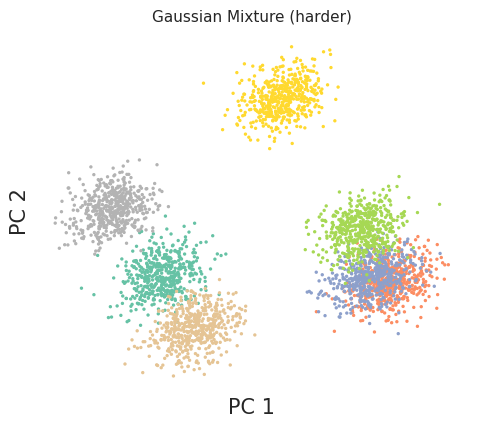

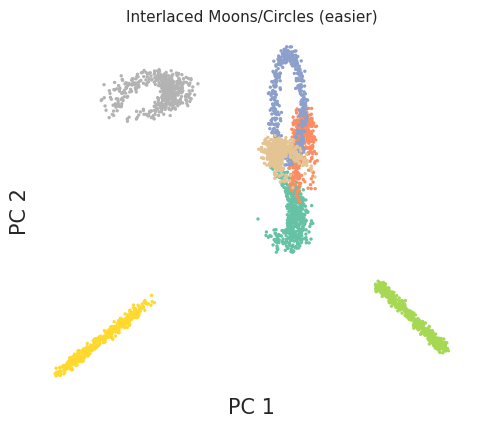

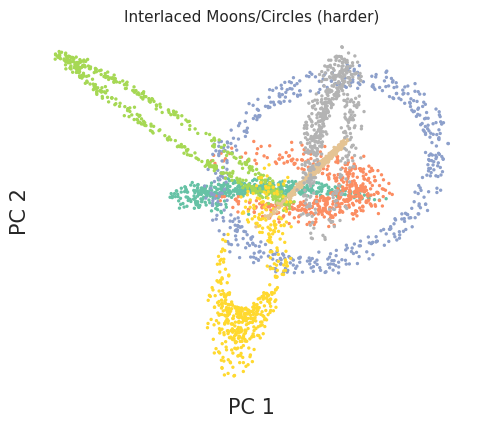

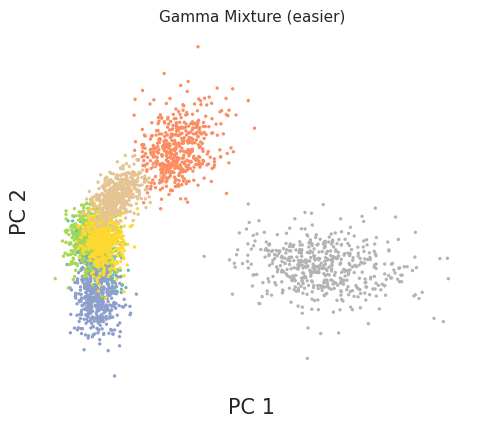

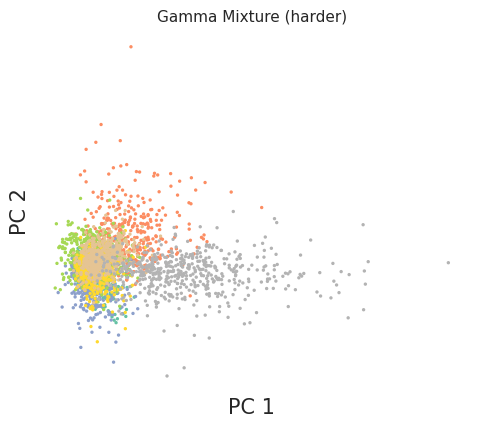

In [34]:
from pathlib import Path
import json
names = ['../scripts/hde/hde1_gaussian.json', '../scripts/hde/hde1_gaussian_medium.json', 
         '../scripts/hde/hde0_moon_easy.json', '../scripts/hde/hde0_moon.json',
         '../scripts/hde/hde2_gamma.json','../scripts/hde/hde2_gamma_alpha1.json']

difficulty = np.tile(['easier','harder'], 3)
simu = np.repeat(['Gaussian Mixture', 'Interlaced Moons/Circles', 'Gamma Mixture'], 2)
path_sim = np.repeat(['gaussian','moons','gamma'], 2)
for i in range(len(names)):
    plot_config_file_pca(
        names[i],
        save_path=f"../figures/{path_sim[i]}_{difficulty[i]}.pdf",
        title=f'{simu[i]} ({difficulty[i]})'
    )
